In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Base directory
base_path = '/content/drive/MyDrive/SKRIPSI_PENTING/hasil'

# Training paths
train_pure = os.path.join(base_path, 'train/pure')
train_treated = os.path.join(base_path, 'train/treated')

# Validation paths
val_pure = os.path.join(base_path, 'validation/pure')
val_treated = os.path.join(base_path, 'validation/treated')

print(f"Data paths configured:\nTrain Pure: {train_pure}\nTrain Treated: {train_treated}\nVal Pure: {val_pure}\nVal Treated: {val_treated}")

Data paths configured:
Train Pure: /content/drive/MyDrive/SKRIPSI_PENTING/hasil/train/pure
Train Treated: /content/drive/MyDrive/SKRIPSI_PENTING/hasil/train/treated
Val Pure: /content/drive/MyDrive/SKRIPSI_PENTING/hasil/validation/pure
Val Treated: /content/drive/MyDrive/SKRIPSI_PENTING/hasil/validation/treated


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Replicating the preprocessing logic
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Creating a main directory structure compatible with flow_from_directory
# Note: flow_from_directory expects subdirectories as classes
train_dir = os.path.join(base_path, 'train')
validation_dir = os.path.join(base_path, 'validation')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 82 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load Pre-trained Model (tanpa top layer)
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Membekukan bobot asal

# 2. Membangun Model di atas Base Model
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Pelatihan Model
history_tl = model_tl.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    verbose=1
)

# 4. Menampilkan Hasil Akhir Sesuai Permintaan
final_loss = history_tl.history['val_loss'][-1]
final_acc = history_tl.history['val_accuracy'][-1]

print("\n" + "="*30)
print(f"HASIL AKHIR PELATIHAN:")
print(f"Validation Loss: {final_loss:.4f}")
print(f"Validation Accuracy: {final_acc:.4f}")
print("="*30)

/tmp/ipykernel_6236/1267323061.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 13s/step - accuracy: 0.5488 - loss: 0.7229 - val_accuracy: 0.6500 - val_loss: 0.5840
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.6829 - loss: 0.7559 - val_accuracy: 0.5000 - val_loss: 0.9619
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step - accuracy: 0.7683 - loss: 0.5816 - val_accuracy: 0.8000 - val_loss: 0.4561
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.6951 - loss: 0.6322 - val_accuracy: 0.6000 - val_loss: 0.6061
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step - accuracy: 0.7561 - loss: 0.4956 - val_accuracy: 0.5500 - val_loss: 0.7356
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.7805 - loss: 0.4236 - val_accuracy: 0.8500 - val_loss: 0.3842
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - accuracy: 0.7805 - loss: 0.4674 - val_accuracy: 0.8500 - val_loss: 0.3706
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.8902 - loss: 0.3195 - val_accuracy: 0.7500 - val_loss: 

Found 20 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


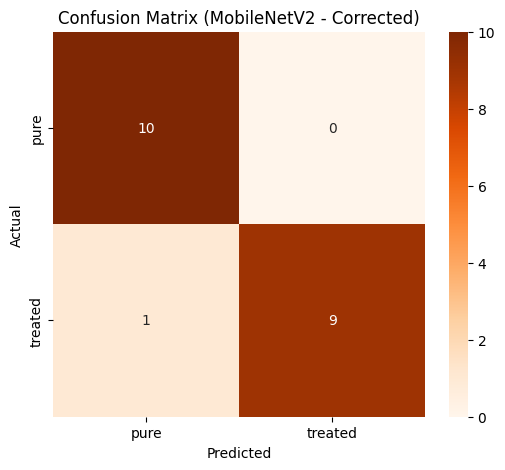

=== Classification Report Transfer Learning (Corrected) ===
              precision    recall  f1-score   support

        pure       0.91      1.00      0.95        10
     treated       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pastikan generator tidak mengacak urutan untuk evaluasi
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 2. Prediksi ulang
Y_pred_tl = model_tl.predict(validation_generator)
y_pred_tl = (Y_pred_tl > 0.5).astype(int)

# 3. Tampilkan Confusion Matrix yang sudah diperbaiki
cm_tl = confusion_matrix(validation_generator.classes, y_pred_tl)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.title('Confusion Matrix (MobileNetV2 - Corrected)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("=== Classification Report Transfer Learning (Corrected) ===")
print(classification_report(validation_generator.classes, y_pred_tl, target_names=validation_generator.class_indices.keys()))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


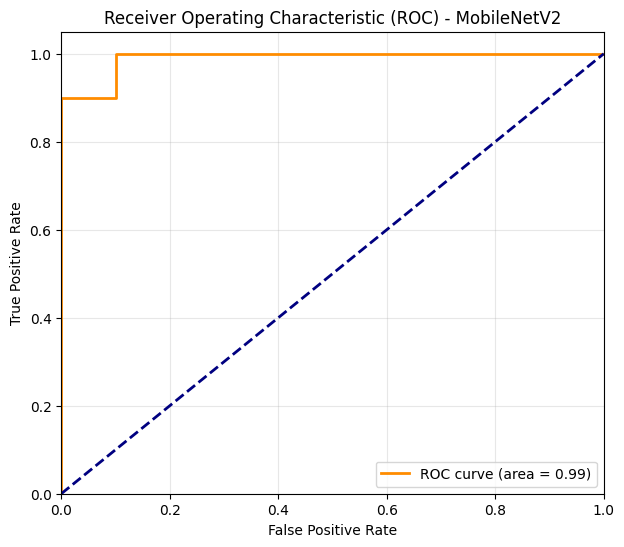

In [ ]:
from sklearn.metrics import roc_curve, auc

# Mendapatkan probabilitas prediksi (bukan label biner)
# validation_generator sudah diatur shuffle=False di cell sebelumnya
y_probs_tl = model_tl.predict(validation_generator).ravel()
y_true_tl = validation_generator.classes

# Hitung ROC curve dan AUC
fpr, tpr, thresholds = roc_curve(y_true_tl, y_probs_tl)
roc_auc = auc(fpr, tpr)

# Plot Kurva ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - MobileNetV2')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


Menguji gambar dari folder PURE:
/content/drive/MyDrive/SKRIPSI_PENTING/hasil/validation/pure/Salinan Salinan Picture4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


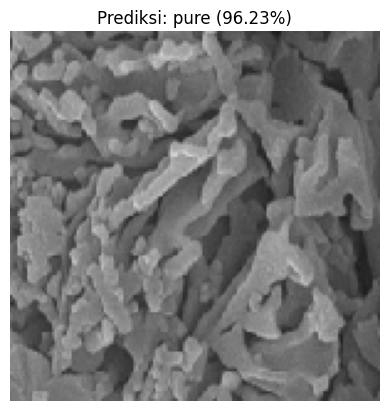


Menguji gambar dari folder TREATED:
/content/drive/MyDrive/SKRIPSI_PENTING/hasil/validation/treated/Salinan Salinan logam5.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


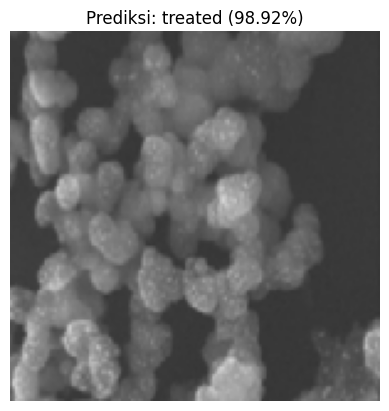

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

def predict_image(image_path):
    img = load_img(image_path, target_size=(150, 150))  # sesuai training
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_tl.predict(img_array)  # pakai model_tl bukan model

    class_indices = train_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}

    predicted_class = 1 if prediction[0][0] > 0.5 else 0
    confidence = prediction[0][0] if predicted_class == 1 else 1 - prediction[0][0]

    # Tampilkan gambar
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {class_names[predicted_class]} ({confidence * 100:.2f}%)")
    plt.show()

# Test dari folder pure dan treated
test_folders = {
    "PURE": val_pure,
    "TREATED": val_treated
}

for label, folder in test_folders.items():
    try:
        sample_files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        if sample_files:
            test_image_path = os.path.join(folder, sample_files[0])
            print(f"\nMenguji gambar dari folder {label}:")
            print(test_image_path)
            predict_image(test_image_path)
        else:
            print(f"Folder {label} kosong.")

    except Exception as e:
        print(f"Error pada folder {label}: {e}")

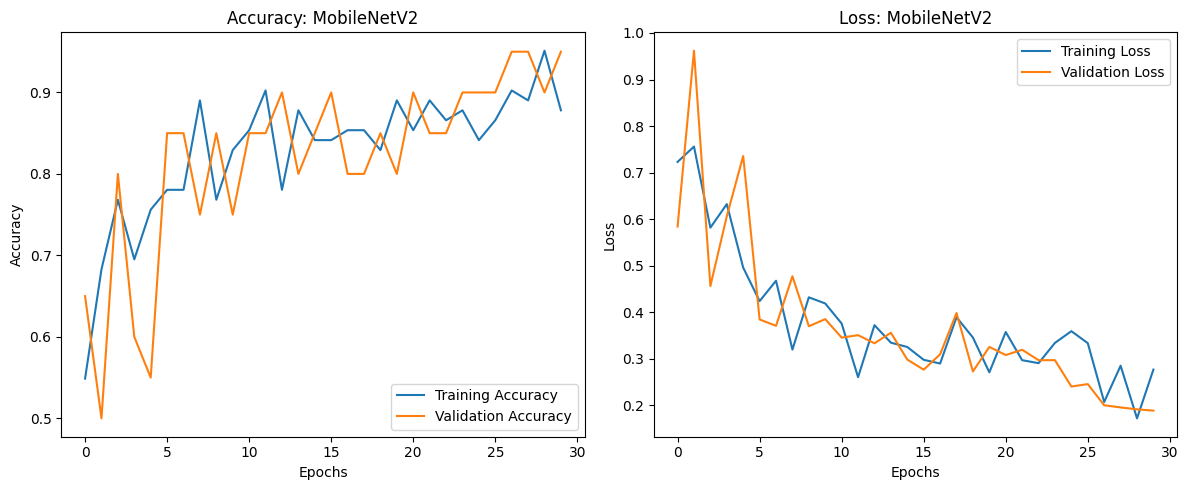

In [ ]:
import matplotlib.pyplot as plt

acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']
loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range = range(len(acc_tl))

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_tl, label='Training Accuracy')
plt.plot(epochs_range, val_acc_tl, label='Validation Accuracy')
plt.title('Accuracy: MobileNetV2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_tl, label='Training Loss')
plt.plot(epochs_range, val_loss_tl, label='Validation Loss')
plt.title('Loss: MobileNetV2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Simpan Model ke Google Drive
model_save_path = os.path.join(base_path, 'model_mobilenetv2_final.h5')
model_tl.save(model_save_path)
print(f"Model berhasil disimpan di: {model_save_path}")

# 2. Fungsi Prediksi untuk Gambar Baru
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    prediction = model_tl.predict(img_array)

    plt.imshow(img)
    plt.axis('off')
    if prediction[0] > 0.5:
        plt.title(f"Prediksi: TREATED ({prediction[0][0]:.2%})")
    else:
        plt.title(f"Prediksi: PURE ({(1-prediction[0][0]):.2%})")
    plt.show()

print("Fungsi predict_image siap digunakan. Masukkan path gambar Anda di bawah.")

Model berhasil disimpan di: /content/drive/MyDrive/SKRIPSI_PENTING/hasil/model_mobilenetv2_final.h5
Fungsi predict_image siap digunakan. Masukkan path gambar Anda di bawah.
